In [5]:
"""
deepONet_cantilever.py

Train a DeepONet to map right-edge vertical traction -> 2D displacement field
for a rectangular cantilever (left edge clamped) using a simple Q4 finite
element solver (plane stress).

Dependencies:
    numpy, scipy, torch, tqdm

Usage:
    python deepONet_cantilever.py
"""

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange, tqdm

# -----------------------
# 1) Finite Element Helper (Q4 bilinear elements, plane stress)
# -----------------------
def make_mesh(L, H, nx, ny):
    """
    Return nodes (Nnodes x 2) and elements (Nelements x 4 node indices)
    Q4 structured mesh (bilinear quads).
    Node numbering row-major.
    """
    xs = np.linspace(0, L, nx + 1)
    ys = np.linspace(0, H, ny + 1)
    xv, yv = np.meshgrid(xs, ys)
    nodes = np.column_stack([xv.ravel(), yv.ravel()])
    elems = []
    for j in range(ny):
        for i in range(nx):
            n0 = j * (nx + 1) + i
            n1 = n0 + 1
            n2 = n0 + (nx + 1) + 1
            n3 = n0 + (nx + 1)
            elems.append([n0, n1, n2, n3])
    return nodes, np.array(elems, dtype=int)

def D_plane_stress(E, nu):
    """Plane stress constitutive matrix (2D)"""
    coeff = E / (1 - nu * nu)
    D = coeff * np.array([[1.0, nu, 0.0],
                          [nu, 1.0, 0.0],
                          [0.0, 0.0, (1 - nu) / 2.0]])
    return D

def quad4_element_stiffness(coords, D):
    """
    Compute 8x8 stiffness matrix for Q4 bilinear element (2x2 Gauss).
    coords: 4x2 array of node coords (in order)
    D: 3x3 constitutive matrix
    """
    # 2x2 Gauss points and weights
    gp = [ -1/np.sqrt(3), 1/np.sqrt(3) ]
    w = [1.0, 1.0]
    Ke = np.zeros((8,8))
    for xi in gp:
        for eta in gp:
            # shape functions derivatives in parent domain
            dN_dxi = np.array([
                [-(1-eta)/4, -(1-xi)/4],  # N1
                [ (1-eta)/4, -(1+xi)/4],  # N2
                [ (1+eta)/4,  (1+xi)/4],  # N3
                [-(1+eta)/4,  (1-xi)/4]   # N4
            ])  # shape: 4x2 -> derivative of N wrt xi,eta
            J = dN_dxi.T @ coords  # 2x2
            detJ = np.linalg.det(J)
            invJ = np.linalg.inv(J)
            dN_dx = dN_dxi @ invJ.T  # 4x2; derivatives wrt x,y
            # B matrix 3x8
            B = np.zeros((3,8))
            for a in range(4):
                idx = 2*a
                B[0, idx]   = dN_dx[a,0]
                B[1, idx+1] = dN_dx[a,1]
                B[2, idx]   = dN_dx[a,1]
                B[2, idx+1] = dN_dx[a,0]
            Ke += (B.T @ D @ B) * detJ * 1.0  # weight product =1 for 2x2 Gauss
    return Ke

def assemble_global_stiffness(nodes, elems, E, nu):
    ndof = nodes.shape[0] * 2
    D = D_plane_stress(E, nu)
    rows = []
    cols = []
    data = []
    for el in range(elems.shape[0]):
        nidx = elems[el]
        coords = nodes[nidx]
        Ke = quad4_element_stiffness(coords, D)
        # assemble
        gdofs = []
        for ni in nidx:
            gdofs += [2*ni, 2*ni+1]
        for i_local, I in enumerate(gdofs):
            for j_local, J in enumerate(gdofs):
                rows.append(I)
                cols.append(J)
                data.append(Ke[i_local, j_local])
    K = sp.coo_matrix((data, (rows, cols)), shape=(ndof, ndof)).tocsr()
    return K

def apply_dirichlet(K, F, bc_dofs):
    """
    Modify K and F to apply zero Dirichlet BCs at bc_dofs (list/array of dof indices).
    Returns modified K (sparse) and F.
    """
    # Zero out rows and columns and put ones on diagonal to keep system solvable
    n = K.shape[0]
    K = K.tolil()
    for dof in bc_dofs:
        K.rows[dof] = [dof]
        K.data[dof] = [1.0]
    K = K.tocsr()
    F = F.copy()
    for dof in bc_dofs:
        F[dof] = 0.0
    # remove columns: set column entries to 0 except diagonal
    # easiest is to rebuild diagonal for bc_dofs
    K = sp.csr_matrix(K)
    return K, F

# -----------------------
# 2) Dataset generation: parameterized traction on right edge -> full displacement field
# -----------------------
def build_right_edge_traction(nodes, nx, ny, traction_samples):
    """
    Convert traction_samples (array of length ny+1 sampled along edge) into nodal force vector
    Traction is vertical only (y-direction). We apply equivalent nodal forces by integrating line load
    using 2-point Gauss across each segment on right edge.
    """
    # right edge nodes have x = max
    tol = 1e-8
    x_max = nodes[:,0].max()
    right_node_ids = np.where(np.abs(nodes[:,0] - x_max) < tol)[0]
    # sort by y
    ycoords = nodes[right_node_ids,1]
    order = np.argsort(ycoords)
    right_node_ids = right_node_ids[order]
    # traction_samples length should be len(right_node_ids)
    # We'll build nodal forces: for each segment connect node i and i+1
    ndof = nodes.shape[0]*2
    F = np.zeros(ndof)
    # linear shape functions on segment: distribute line load to the two nodes
    for i in range(len(right_node_ids)-1):
        n1 = right_node_ids[i]
        n2 = right_node_ids[i+1]
        y1 = nodes[n1,1]
        y2 = nodes[n2,1]
        length = np.abs(y2 - y1)
        # sample traction at nodes and average for segment
        t1 = traction_samples[i]
        t2 = traction_samples[i+1]
        # equivalent nodal forces for line load in y-direction over segment:
        # f1 = (t1*2 + t2) * length / 6 ; f2 = (t1 + t2*2) * length / 6  (from linear shape fns)
        f1 = (2*t1 + t2) * length / 6.0
        f2 = (t1 + 2*t2) * length / 6.0
        F[2*n1+1] += f1
        F[2*n2+1] += f2
    return F, right_node_ids

def generate_dataset(L, H, nx, ny, E, nu, nsamples, n_trac_samples, seed=123):
    """
    Generate dataset of (traction_vector_on_edge, nodes_coords, displacements) pairs.
    traction vectors are sampled as small linear combinations of sine modes along the free edge.
    Returns:
      inputs: list of traction vectors (nsamples x n_trac_samples)
      coords: Ncoords x 2 (same for all samples)
      sols: nsamples x (Ncoords*2) flattened displacement vector (u_x1, u_y1, u_x2, u_y2, ...)
    """
    np.random.seed(seed)
    nodes, elems = make_mesh(L, H, nx, ny)
    K = assemble_global_stiffness(nodes, elems, E, nu)
    ndof = nodes.shape[0]*2

    # BCs: left edge (x=0) clamped: both dofs = 0
    left_ids = np.where(np.abs(nodes[:,0]) < 1e-8)[0]
    bc_dofs = []
    for nid in left_ids:
        bc_dofs += [2*nid, 2*nid+1]

    coords = nodes.copy()
    # build modal basis on right edge
    right_ids = np.where(np.abs(nodes[:,0] - L) < 1e-8)[0]
    ycoords = nodes[right_ids,1]
    order = np.argsort(ycoords)
    right_ids = right_ids[order]
    # sample points along right edge for traction representation
    ys = nodes[right_ids,1]
    # generate functions: small number of sine modes
    modes = [1,2,3]
    inputs = []
    sols = []
    for s in tqdm(range(nsamples), desc="Generating FEM samples"):
        # random coefficients
        coeffs = 0.5 * np.random.randn(len(modes))
        traction = np.zeros_like(ys)
        for i,m in enumerate(modes):
            traction += coeffs[i] * np.sin(np.pi * m * (ys / H))
        # optionally add a constant downward load
        traction += 0.0 * (np.random.rand()-0.5)
        # build nodal force vector
        F_edge, _ = build_right_edge_traction(nodes, nx, ny, traction)
        F = F_edge
        # apply BCs
        Kmod, Fmod = apply_dirichlet(K, F, bc_dofs)
        # solve
        u = spla.spsolve(Kmod, Fmod)
        inputs.append(traction.copy())
        sols.append(u.copy())
    inputs = np.vstack(inputs)  # nsamples x n_trac_samples
    sols = np.vstack(sols)      # nsamples x (ndof)
    return inputs, coords, sols, right_ids, elems

# -----------------------
# 3) DeepONet model (branch + trunk)
# -----------------------
class BranchNet(nn.Module):
    def __init__(self, in_dim, hidden=[128,128,64]):
        super().__init__()
        layers = []
        last = in_dim
        for h in hidden:
            layers.append(nn.Linear(last, h))
            layers.append(nn.ReLU())
            last = h
        # final embedding dimension (branch output size)
        layers.append(nn.Linear(last, 64))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        # x: batch x in_dim
        return self.net(x)  # batch x 64

class TrunkNet(nn.Module):
    def __init__(self, in_dim=2, hidden=[128,128,64]):
        super().__init__()
        layers = []
        last = in_dim
        for h in hidden:
            layers.append(nn.Linear(last, h))
            layers.append(nn.ReLU())
            last = h
        layers.append(nn.Linear(last, 64))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)  # batch x 64

class DeepONet(nn.Module):
    def __init__(self, branch_dim, trunk_dim=2, out_dim=2):
        super().__init__()
        self.branch = BranchNet(branch_dim)
        self.trunk = TrunkNet(trunk_dim)
        # final linear maps from inner product features to output (u_x, u_y)
        # We'll compute dot product between branch embedding and trunk embedding for each output channel:
        # i.e., y_k = (B * T).sum(dim=1) + bias_k  -> To allow separate linear comb, use a linear layer.
        # Implementation: elementwise multiply then linear map to out_dim
        self.final = nn.Linear(64, out_dim)

    def forward(self, branch_in, trunk_in):
        # branch_in: batch x bdim
        # trunk_in: batch x tdim
        B = self.branch(branch_in)
        T = self.trunk(trunk_in)
        # element-wise product
        H = B * T
        out = self.final(H)
        return out  # batch x out_dim

# -----------------------
# 4) Training utilities: dataset creation for training the operator
# -----------------------
class OperatorDataset(torch.utils.data.Dataset):
    def __init__(self, traction_vectors, coords, sols, sample_coords=None, subsample=1):
        """
        traction_vectors: ns x m
        coords: Nnodes x 2
        sols: ns x (2*Nnodes)
        We will return per sample many (branch_vec, coord) pairs with target u at coord.
        If subsample>1, we randomly sample coordinates to reduce dataset size.
        sample_coords: array of indices of coords to use (optional)
        """
        self.traces = traction_vectors.astype(np.float32)
        self.coords = coords.astype(np.float32)
        self.sols = sols.astype(np.float32)
        self.nsamples = self.traces.shape[0]
        self.ncoords = self.coords.shape[0]
        if sample_coords is None:
            # choose uniform subset of coords if subsample>1
            if subsample == 1:
                self.sample_idx = np.arange(self.ncoords)
            else:
                self.sample_idx = np.random.choice(self.ncoords, max(10, self.ncoords//subsample), replace=False)
        else:
            self.sample_idx = np.array(sample_coords, dtype=int)
        # Build flattened dataset where each item is (sample_id, coord_id)
        pairs = []
        for s in range(self.nsamples):
            for ci in self.sample_idx:
                pairs.append((s, ci))
        self.pairs = pairs

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        s, ci = self.pairs[idx]
        branch = self.traces[s]  # m
        coord = self.coords[ci]  # (x,y)
        # target displacement (u_x, u_y) at node ci
        ux = self.sols[s, 2*ci]
        uy = self.sols[s, 2*ci+1]
        target = np.array([ux, uy], dtype=np.float32)
        return branch, coord, target

# -----------------------
# 5) Training script
# -----------------------
def train_deeponet(L=1.0, H=0.2, nx=20, ny=6, E=2.1e11, nu=0.3,
                   nsamples=120, epochs=80, batch_size=512, lr=1e-3, device='cpu'):
    # 1) generate dataset
    n_trac_samples = ny + 1
    print("Generating FEM dataset...")
    tractions, coords, sols, right_ids, elems = generate_dataset(L, H, nx, ny, E, nu, nsamples, n_trac_samples)
    ns, m = tractions.shape
    # normalize branch inputs (traction) and coords/targets
    b_mean = tractions.mean(0)
    b_std  = tractions.std(0) + 1e-8
    t_mean = sols.mean(axis=0)
    t_std  = sols.std(axis=0) + 1e-8
    coords_mean = coords.mean(axis=0)
    coords_std  = coords.std(axis=0) + 1e-8

    tr_norm = (tractions - b_mean) / b_std
    sols_norm = (sols - t_mean) / t_std
    coords_norm = (coords - coords_mean) / coords_std

    dataset = OperatorDataset(tr_norm, coords_norm, sols_norm, subsample=1)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=False)

    # build model
    model = DeepONet(branch_dim=m, trunk_dim=2, out_dim=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # training loop
    for ep in range(epochs):
        model.train()
        running_loss = 0.0
        for batch in loader:
            branch_b, coord_b, target_b = batch
            branch_b = branch_b.to(device)
            coord_b = coord_b.to(device)
            target_b = target_b.to(device)
            optimizer.zero_grad()
            pred = model(branch_b, coord_b)  # batch x 2
            loss = criterion(pred, target_b)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * branch_b.shape[0]
        epoch_loss = running_loss / len(dataset)
        if (ep+1) % 5 == 0 or ep == 0:
            print(f"Epoch {ep+1}/{epochs}  loss={epoch_loss:.4e}")
    # return trained model and scalers and mesh info
    scalers = dict(b_mean=b_mean, b_std=b_std, t_mean=t_mean, t_std=t_std, coords_mean=coords_mean, coords_std=coords_std)
    return model, scalers, (coords, sols, right_ids, elems)

# -----------------------
# 6) Example usage and evaluation at nodes (no plotting)
# -----------------------
if __name__ == "__main__":
    device = 'cpu'  # change to 'cuda' if GPU available and torch installed with CUDA
    model, scalers, mesh_info = train_deeponet(L=1.0, H=0.2, nx=24, ny=8,
                                               E=2.1e11, nu=0.3,
                                               nsamples=200, epochs=60,
                                               batch_size=1024, lr=1e-3,
                                               device=device)
    # quick evaluation on one sample from dataset generation
    coords, sols, right_ids, elems = mesh_info
    # pick a random traction sample and compute predicted displacements at all nodes
    # For convenience re-generate one traction (same sampling method)
    # Here: just test on first training sample (you could generate new random traction)
    print("Running inference on first training sample (re-using dataset scalers).")
    # We'll create a traction vector of zeros except a small downward sinusoidal shape
    ys = coords[right_ids,1]
    sample_trac = 0.4 * np.sin(np.pi * 1 * (ys / np.max(ys)))
    # normalize using scalers
    b_mean = scalers['b_mean']; b_std = scalers['b_std']
    coords_mean = scalers['coords_mean']; coords_std = scalers['coords_std']
    t_mean = scalers['t_mean']; t_std = scalers['t_std']
    b_in = (sample_trac - b_mean) / b_std
    # prepare branch repeated for each coord
    B = np.tile(b_in.astype(np.float32), (coords.shape[0],1))
    C = (coords - coords_mean) / coords_std
    with torch.no_grad():
        model.eval()
        B_t = torch.from_numpy(B).to(device)
        C_t = torch.from_numpy(C.astype(np.float32)).to(device)
        pred_norm = model(B_t, C_t).cpu().numpy()  # Nnodes x 2
    # un-normalize predictions
    # note: t_mean and t_std are for full solution vector (u_x1,u_y1,u_x2,...). For simplicity we unnormalize per-entry:
    # We'll build mean/std per node component
    t_mean_nodes = t_mean.reshape(-1,2)
    t_std_nodes  = t_std.reshape(-1,2)
    # But the model predicted normalized u_x,u_y with the global scalers (we used global flatten). For simplicity, assume t_mean_nodes[0] ~ ...
    # To be consistent we need to unnormalize using global flatten pattern: target = pred * t_std_flat + t_mean_flat
    # Build flat arrays for the two components
    t_mean_flat = t_mean
    t_std_flat  = t_std
    # pred_norm is N x 2 -> flatten to 2N and unnormalize
    pred_flat_norm = pred_norm.reshape(-1)
    # create predictor flat: (u_x1,u_y1,...)
    # To un-normalize, we need the same ordering used in dataset: sols stored as [u0,u1,u2,...] with u0=ux_node0, u1=uy_node0,...
    # So build t_mean and t_std as we have, then reconstruct predicted flat:
    # Interleave pred_norm:
    Nnodes = coords.shape[0]
    pred_interleaved = np.zeros(2*Nnodes)
    pred_interleaved[0::2] = pred_norm[:,0]
    pred_interleaved[1::2] = pred_norm[:,1]
    pred_unnorm_flat = pred_interleaved * t_std_flat + t_mean_flat
    # final predicted nodal displacements:
    pred_ux = pred_unnorm_flat[0::2]
    pred_uy = pred_unnorm_flat[1::2]
    print("Example prediction min/max u_x, u_y:")
    print("u_x: ", pred_ux.min(), pred_ux.max())
    print("u_y: ", pred_uy.min(), pred_uy.max())

    print("Done. Model and scalers returned for further use.")


Generating FEM dataset...


Generating FEM samples: 100%|████████████████████████████████████████████████████████| 200/200 [00:00<00:00, 283.16it/s]


Epoch 1/60  loss=5.9043e-04
Epoch 5/60  loss=6.9003e-07
Epoch 10/60  loss=1.7314e-07
Epoch 15/60  loss=8.0414e-08
Epoch 20/60  loss=4.9171e-08
Epoch 25/60  loss=3.4986e-08
Epoch 30/60  loss=2.7190e-08
Epoch 35/60  loss=2.1377e-08
Epoch 40/60  loss=1.7819e-08
Epoch 45/60  loss=1.6414e-08
Epoch 50/60  loss=1.4862e-08
Epoch 55/60  loss=3.2749e-08
Epoch 60/60  loss=1.1147e-08
Running inference on first training sample (re-using dataset scalers).
Example prediction min/max u_x, u_y:
u_x:  -1.656932754888705e-11 1.9715883282737977e-11
u_y:  -3.915280103683472e-13 1.1785369098083746e-10
Done. Model and scalers returned for further use.


In [8]:
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
import numpy as np
import torch

def plot_compare_displacement(model, traction_vec, coords, fem_u, L, H, device='cpu'):
    """
    model: trained DeepONet
    traction_vec: (n_trac_samples,) numpy vector
    coords: (N,2) node coordinates
    fem_u: (2N,) FEM displacement vector
    """

    # --- 1. Prepare grid for smooth visualization ---
    x = coords[:,0]
    y = coords[:,1]

    grid_x, grid_y = np.mgrid[0:L:200j, 0:H:200j]
    pts = np.column_stack([x, y])

    # --- 2. FEM displacement field ---
    fem_ux = fem_u[0::2]
    fem_uy = fem_u[1::2]

    fem_ux_grid = griddata(pts, fem_ux, (grid_x, grid_y), method='cubic')
    fem_uy_grid = griddata(pts, fem_uy, (grid_x, grid_y), method='cubic')

    # --- 3. DeepONet prediction ---
    traction_t = torch.tensor(traction_vec, dtype=torch.float32).to(device)

    coords_t = torch.tensor(coords, dtype=torch.float32).to(device)
    traj = traction_t.unsqueeze(0).repeat(coords_t.shape[0],1)

    with torch.no_grad():
        pred = model(traj, coords_t).cpu().numpy()

    pred_ux = pred[:,0]
    pred_uy = pred[:,1]

    pred_ux_grid = griddata(pts, pred_ux, (grid_x, grid_y), method='cubic')
    pred_uy_grid = griddata(pts, pred_uy, (grid_x, grid_y), method='cubic')

    # --- 4. Plot ---
    fig, ax = plt.subplots(2,2, figsize=(12,10))

    im0 = ax[0,0].pcolormesh(grid_x, grid_y, fem_ux_grid, shading='auto')
    ax[0,0].set_title("FEM u_x")
    plt.colorbar(im0, ax=ax[0,0])

    im1 = ax[0,1].pcolormesh(grid_x, grid_y, pred_ux_grid, shading='auto')
    ax[0,1].set_title("DeepONet u_x")
    plt.colorbar(im1, ax=ax[0,1])

    im2 = ax[1,0].pcolormesh(grid_x, grid_y, fem_uy_grid, shading='auto')
    ax[1,0].set_title("FEM u_y")
    plt.colorbar(im2, ax=ax[1,0])

    im3 = ax[1,1].pcolormesh(grid_x, grid_y, pred_uy_grid, shading='auto')
    ax[1,1].set_title("DeepONet u_y")
    plt.colorbar(im3, ax=ax[1,1])

    for a in ax.flat:
        a.set_xlabel("x")
        a.set_ylabel("y")

    plt.tight_layout()
    plt.show()


Epoch 1/6000  Loss=2.668e+09  PDE=1.549e+08  Dir=2.647e-02  Neu=3.664e+06  Free=2.476e+08
Epoch 200/6000  Loss=1.734e+06  PDE=8.533e+05  Dir=6.050e-03  Neu=5.151e+04  Free=3.655e+04
Epoch 400/6000  Loss=4.496e+05  PDE=1.692e+05  Dir=2.155e-03  Neu=2.270e+04  Free=5.336e+03
Epoch 600/6000  Loss=2.302e+05  PDE=8.185e+04  Dir=6.144e-04  Neu=1.170e+04  Free=3.140e+03
Epoch 800/6000  Loss=1.712e+05  PDE=6.493e+04  Dir=1.297e-04  Neu=7.774e+03  Free=2.849e+03
Epoch 1000/6000  Loss=1.183e+05  PDE=4.885e+04  Dir=1.586e-05  Neu=4.592e+03  Free=2.354e+03
Epoch 1200/6000  Loss=8.192e+04  PDE=3.745e+04  Dir=6.903e-07  Neu=2.653e+03  Free=1.794e+03
Epoch 1400/6000  Loss=5.506e+04  PDE=2.707e+04  Dir=1.272e-06  Neu=1.411e+03  Free=1.388e+03
Epoch 1600/6000  Loss=3.413e+04  PDE=1.844e+04  Dir=1.785e-06  Neu=6.018e+02  Free=9.671e+02
Epoch 1800/6000  Loss=2.292e+04  PDE=1.320e+04  Dir=1.316e-06  Neu=2.621e+02  Free=7.100e+02
Epoch 2000/6000  Loss=1.613e+04  PDE=9.313e+03  Dir=8.516e-07  Neu=1.062e+02 

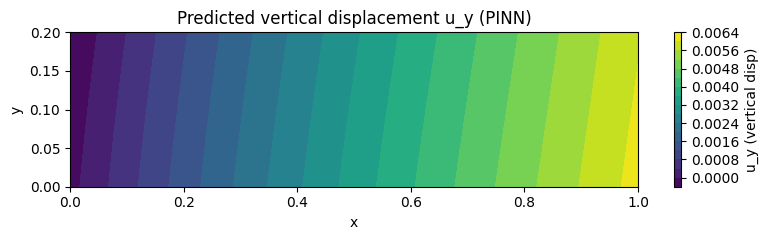

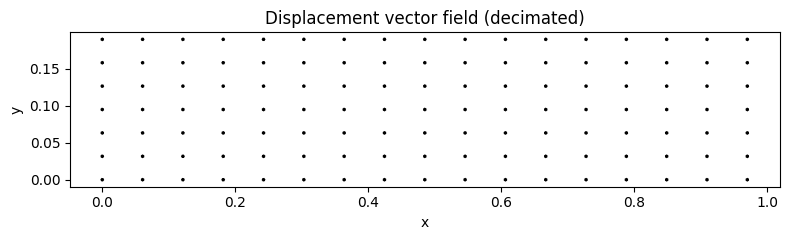

In [10]:
# PINN for 2D linear elasticity cantilever (PyTorch)
# Solve for displacement field u=(u_x,u_y) in domain [0,L] x [0,H]
# Left edge x=0: u=0 (fixed). Right edge x=L: applied traction t_y = -T (uniform downward).
# Top/bottom: traction = 0 (free).
#
# Dependencies:
# pip install torch numpy matplotlib

import torch
import torch.nn as nn
import numpy as np
import math
import random
import matplotlib.pyplot as plt

# ---------------------------
# Problem / material params
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

L = 1.0         # beam length
H = 0.2         # beam height
E = 210e3       # Young's modulus (MPa) or consistent units
nu = 0.3        # Poisson ratio
T = 5.0         # downward traction magnitude (force per length) on right edge

# Lamé parameters
mu = E / (2*(1+nu))
lam = E*nu / ((1+nu)*(1-2*nu))

# Training hyperparams
n_interior = 4000
n_left = 400       # Dirichlet boundary points (x=0)
n_right = 400      # Neumann boundary points (x=L)
n_topbot = 400     # top+bottom traction zero points
lr = 2e-4
epochs = 6000
print_every = 200
plot_results = True   # set False to skip plotting

# ---------------------------
# Neural network (PINN)
# ---------------------------
class PINN(nn.Module):
    def __init__(self, layers):
        super().__init__()
        self.layers = nn.ModuleList()
        for i in range(len(layers)-1):
            self.layers.append(nn.Sequential(
                nn.Linear(layers[i], layers[i+1]),
                nn.Tanh()
            ))
        # remove activation on last layer
        self.layers[-1] = nn.Linear(layers[-2], layers[-1])

    def forward(self, x):
        # x: [N,2] (x,y)
        out = x
        for i,layer in enumerate(self.layers):
            out = layer(out)
        # output u_x, u_y
        return out

# network size
net = PINN([2, 64, 64, 64, 64, 2]).to(device)

# ---------------------------
# Sampling points
# ---------------------------
def sampler_interior(n):
    x = np.random.rand(n,1) * L
    y = np.random.rand(n,1) * H
    return np.hstack([x,y])

def sampler_left(n):
    x = np.zeros((n,1))
    y = np.random.rand(n,1) * H
    return np.hstack([x,y])

def sampler_right(n):
    x = np.ones((n,1))*L
    y = np.random.rand(n,1) * H
    return np.hstack([x,y])

def sampler_topbot(n):
    # half top, half bottom
    n2 = n//2
    x_top = np.random.rand(n2,1)*L
    y_top = np.ones((n2,1))*H
    x_bot = np.random.rand(n-n2,1)*L
    y_bot = np.zeros((n-n2,1))
    return np.vstack([np.hstack([x_top,y_top]), np.hstack([x_bot,y_bot])])

# Convert to torch
def to_tensor(arr):
    return torch.tensor(arr, dtype=torch.float32, requires_grad=True, device=device)

# ---------------------------
# PDE residuals (auto-diff)
# ---------------------------
def elasticity_residual(xy):  # xy tensor [N,2] with requires_grad=True
    xy = xy.clone().requires_grad_(True)
    u = net(xy)                          # [N,2]
    u_x = u[:,0:1]
    u_y = u[:,1:2]

    # gradients
    grads = torch.autograd.grad(u.sum(), xy, create_graph=True)[0]  # WRONG: u.sum() won't work for vector grads
    # We need component-wise grads instead:
    ux_grad = torch.autograd.grad(u_x, xy, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    uy_grad = torch.autograd.grad(u_y, xy, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]

    # components
    u_x_x = ux_grad[:,0:1]   # du_x/dx
    u_x_y = ux_grad[:,1:2]   # du_x/dy
    u_y_x = uy_grad[:,0:1]   # du_y/dx
    u_y_y = uy_grad[:,1:2]   # du_y/dy

    # strain components (small strain)
    eps_xx = u_x_x
    eps_yy = u_y_y
    eps_xy = 0.5*(u_x_y + u_y_x)

    # stress components using Hooke's law (plane stress or plane strain?)
    # We'll use plane stress formulation here:
    # For plane stress: sigma_xx = E/(1-nu**2) * (eps_xx + nu*eps_yy)
    # But to keep general we use lamé form (plane strain is consistent with lam,mu)
    # Use 2D constitutive via lam, mu:
    trace = eps_xx + eps_yy
    sigma_xx = lam*trace + 2*mu*eps_xx
    sigma_yy = lam*trace + 2*mu*eps_yy
    sigma_xy = 2*mu*eps_xy

    # equilibrium: div(sigma) + body = 0 -> two equations
    # compute derivatives of stress
    sx_grad = torch.autograd.grad(sigma_xx, xy, grad_outputs=torch.ones_like(sigma_xx), create_graph=True)[0]
    sy_grad = torch.autograd.grad(sigma_xy, xy, grad_outputs=torch.ones_like(sigma_xy), create_graph=True)[0]
    # div sigma x-comp: d(sigma_xx)/dx + d(sigma_xy)/dy
    div_sigma_x = sx_grad[:,0:1] + sy_grad[:,1:2]

    sx2_grad = torch.autograd.grad(sigma_xy, xy, grad_outputs=torch.ones_like(sigma_xy), create_graph=True)[0]
    sy2_grad = torch.autograd.grad(sigma_yy, xy, grad_outputs=torch.ones_like(sigma_yy), create_graph=True)[0]
    # div sigma y-comp: d(sigma_xy)/dx + d(sigma_yy)/dy
    div_sigma_y = sx2_grad[:,0:1] + sy2_grad[:,1:2]

    # residuals (no body forces)
    r1 = div_sigma_x
    r2 = div_sigma_y

    return r1, r2

# ---------------------------
# Boundary traction evaluation
# ---------------------------
def traction_mismatch(right_xy):
    # compute traction = sigma . n on right edge (normal = +x)
    right_xy = right_xy.clone().requires_grad_(True)
    u = net(right_xy)
    u_x = u[:,0:1]
    u_y = u[:,1:2]

    # compute displacement gradients
    ux_grad = torch.autograd.grad(u_x, right_xy, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    uy_grad = torch.autograd.grad(u_y, right_xy, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    u_x_x = ux_grad[:,0:1]
    u_x_y = ux_grad[:,1:2]
    u_y_x = uy_grad[:,0:1]
    u_y_y = uy_grad[:,1:2]

    eps_xx = u_x_x
    eps_yy = u_y_y
    eps_xy = 0.5*(u_x_y + u_y_x)
    trace = eps_xx + eps_yy
    sigma_xx = lam*trace + 2*mu*eps_xx
    sigma_yy = lam*trace + 2*mu*eps_yy
    sigma_xy = 2*mu*eps_xy

    # normal vector at right edge is [1,0]
    # traction components t = sigma * n => [sigma_xx, sigma_xy]
    tx = sigma_xx
    ty = sigma_xy

    # prescribed traction: downward T => (0, -T)
    t_x_pres = torch.zeros_like(tx)
    t_y_pres = -T * torch.ones_like(ty)

    mismatch_x = tx - t_x_pres
    mismatch_y = ty - t_y_pres

    return mismatch_x, mismatch_y

def traction_topbot(xy):
    # For top/bottom edges traction = 0 vector
    xy = xy.clone().requires_grad_(True)
    u = net(xy)
    u_x = u[:,0:1]
    u_y = u[:,1:2]

    ux_grad = torch.autograd.grad(u_x, xy, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
    uy_grad = torch.autograd.grad(u_y, xy, grad_outputs=torch.ones_like(u_y), create_graph=True)[0]
    u_x_x = ux_grad[:,0:1]; u_x_y = ux_grad[:,1:2]
    u_y_x = uy_grad[:,0:1]; u_y_y = uy_grad[:,1:2]

    eps_xx = u_x_x
    eps_yy = u_y_y
    eps_xy = 0.5*(u_x_y + u_y_x)
    trace = eps_xx + eps_yy
    sigma_xx = lam*trace + 2*mu*eps_xx
    sigma_yy = lam*trace + 2*mu*eps_yy
    sigma_xy = 2*mu*eps_xy

    # normals: top edge n = [0,1], bottom n=[0,-1]; traction = [sigma_xy, sigma_yy]
    tx = sigma_xy
    ty = sigma_yy

    # prescribed traction = 0
    return tx, ty

# ---------------------------
# Loss and optimizer
# ---------------------------
optimizer = torch.optim.Adam(net.parameters(), lr=lr)

# for stability: small weight for Neumann enforcement maybe
w_pde = 1.0
w_dir = 100.0
w_neu = 10.0
w_free = 10.0

# Training loop
for ep in range(1, epochs+1):
    net.train()
    optimizer.zero_grad()

    # sample points
    X_int = to_tensor(sampler_interior(n_interior))
    X_left = to_tensor(sampler_left(n_left))
    X_right = to_tensor(sampler_right(n_right))
    X_topbot = to_tensor(sampler_topbot(n_topbot))

    # PDE residual
    r1, r2 = elasticity_residual(X_int)
    loss_pde = (r1.pow(2).mean() + r2.pow(2).mean())

    # Dirichlet left: u = 0
    u_left = net(X_left)
    loss_dir = (u_left.pow(2).mean())

    # Neumann right: traction mismatch
    tm_x, tm_y = traction_mismatch(X_right)
    loss_neu = (tm_x.pow(2).mean() + tm_y.pow(2).mean())

    # Free traction top/bot = 0
    ft_x, ft_y = traction_topbot(X_topbot)
    loss_free = (ft_x.pow(2).mean() + ft_y.pow(2).mean())

    loss = w_pde*loss_pde + w_dir*loss_dir + w_neu*loss_neu + w_free*loss_free

    loss.backward()
    optimizer.step()

    # print
    if ep % print_every == 0 or ep==1:
        print(f"Epoch {ep}/{epochs}  Loss={loss.item():.3e}  PDE={loss_pde.item():.3e}  Dir={loss_dir.item():.3e}  Neu={loss_neu.item():.3e}  Free={loss_free.item():.3e}")

# ---------------------------
# Inference: grid of points
# ---------------------------
net.eval()
nx = 100
ny = 20
xs = np.linspace(0, L, nx)
ys = np.linspace(0, H, ny)
grid = np.array([[x,y] for y in ys for x in xs], dtype=np.float32)
grid_t = torch.tensor(grid, dtype=torch.float32, device=device)
with torch.no_grad():
    u_pred = net(grid_t).cpu().numpy()

ux = u_pred[:,0].reshape(ny,nx)
uy = u_pred[:,1].reshape(ny,nx)

# Save results to file
np.savez("pinn_cantilever_displacement.npz", xs=xs, ys=ys, ux=ux, uy=uy)
print("Saved displacement field to pinn_cantilever_displacement.npz")

# ---------------------------
# Optional minimal plotting
# ---------------------------
if plot_results:
    # show vertical displacement contour
    Xg, Yg = np.meshgrid(xs, ys)
    plt.figure(figsize=(8,2.5))
    cs = plt.contourf(Xg, Yg, uy, levels=20)
    plt.colorbar(cs, label='u_y (vertical disp)')
    plt.title('Predicted vertical displacement u_y (PINN)')
    plt.xlabel('x'); plt.ylabel('y')
    plt.tight_layout()
    plt.show()

    # quiver plot (decimated)
    skipx = 6
    skipy = 3
    plt.figure(figsize=(8,2.5))
    plt.quiver(Xg[::skipy,::skipx], Yg[::skipy,::skipx],
               ux[::skipy,::skipx], uy[::skipy,::skipx], scale=1.0/1e-3)
    plt.title('Displacement vector field (decimated)')
    plt.xlabel('x'); plt.ylabel('y')
    plt.tight_layout()
    plt.show()
